# Searching for Correlates in fMRI Data — Circular Analysis ("Double Dipping")

This notebook is a Python translation of `Version1SampleSolution.m`.

## Motivation

The purpose of this exercise is to explore how a data-analysis *workflow* can influence
the validity of a study, and to show how simulations can be used to validate an analysis
workflow **before** applying it to real data — or even before collecting data.

We use an example from cognitive neuroscience. In many studies, researchers search for
brain regions whose activity (in some task) is correlated with a behavioural or
psychological measure. A common workflow is:

1. Identify the brain regions whose activity correlates with the psychological measure.
2. Average the activity in those identified regions.
3. Test how well this aggregate "brain network activity" score correlates with the trait.

We simulate this experiment and analysis in two cases:

- **Question 1 — ground truth is *no effect*** (brain activity is unrelated to the test score).
- **Question 2 — ground truth is a *real effect*** (the test score genuinely modulates brain activity).

The key lesson: selecting voxels by their correlation with the score and then re-testing
that same correlation on the selected voxels produces a spurious "significant" result even
when there is no real effect.

**Dependencies:** `numpy`, `matplotlib`, `scipy` (only for statistics).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

## Helper: column-wise correlation (equivalent to MATLAB `corr`)

MATLAB's `[r, p] = corr(DA, T)` returns, for each column (voxel) of `DA`, the Pearson
correlation `r` with the vector `T` and its two-tailed p-value `p`. We replicate that
in a vectorized way.

In [2]:
def corr_columns(X, y):
    """Pearson correlation of each column of X (n x p) with vector y (n,).

    Returns (r, p) each of length p, matching MATLAB's corr(X, y).
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    with np.errstate(divide="ignore", invalid="ignore"):
        r = (Xc * yc[:, None]).sum(axis=0) / denom
    r = np.clip(r, -1.0, 1.0)
    df = n - 2
    with np.errstate(divide="ignore", invalid="ignore"):
        t = r * np.sqrt(df / (1 - r ** 2))
    p = 2 * stats.t.sf(np.abs(t), df)
    return r, p


def bestfit_line(ax, x, y):
    """Plot the least-squares best fit line (equivalent to MATLAB lsline)."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    b, a = np.polyfit(x, y, 1)  # slope, intercept
    xl = np.array(ax.get_xlim())
    ax.plot(xl, b * xl + a, "-", color="tab:orange")
    ax.set_xlim(xl)

# Preparations

Suppose we tested `Nsubj = 12` subjects in a study involving a psychological test and a
brain scan.

## Subjects and psychology test scores

First, for each subject we perform a psychological test for some personality trait, giving
a score $T$. To simulate this, we draw a score for each subject at random from a normal
distribution with mean $\mu_T = 50$ and standard deviation $\sigma_T = 10$.

(Making $T$ an integer is not required by the instructions — it just mimics a realistic
test score.)


In [3]:
Nsubj = 12
mT, sT = 50, 10
T = sT * rng.standard_normal(Nsubj) + mT
T = np.round(T)  # not required, but make the score an integer
T

array([51., 49., 56., 51., 45., 54., 63., 59., 43., 37., 44., 50.])

## Simulating the fMRI brain scan (voxel setup)

For each subject we simulate an fMRI brain scan measuring the increase in brain activity
(BOLD signal) in a test condition relative to a control condition — the *differential
activity*. This is measured separately in each of `Nvox = 5000` voxels (cubic volumes in
the brain). For simplicity we assume we can find the corresponding voxels in all 12 brains
and that the same voxels are modulated by the task in every subject. Although real data
would be a 3D volume, we keep the voxels in a 1D vector.

We simulate that **10% of the voxels really are affected** by the task condition
("task-dependent" voxels), drawn from a normal distribution with $\mu_A = 1$, $\sigma_A = 1$.
The remaining voxels have no difference in activity on average ("task-independent" voxels),
drawn from a normal distribution with $\mu_B = 0$, $\sigma_B = \sigma_A$.

**Here's the key point:** although the differential activity really is related to the task
done in the scanner (some voxels genuinely light up), in Question 1 that activity is
*completely unrelated to the psychological test in any voxel*. Let's see how often we would
be fooled into thinking the brain activity and test scores are related, when we know they
are not.


In [4]:
Nvox = 5000
Naffected = round(0.1 * Nvox)
TaskDependentVoxels = np.arange(0, Naffected)
TaskIndependentVoxels = np.arange(Naffected, Nvox)

print(TaskDependentVoxels.shape)
print(TaskIndependentVoxels.shape)
print(Naffected)

(500,)
(4500,)
500


# Question 1 — Standard analysis method, **no real effect**

We replicate a common data-analysis workflow to identify brain areas whose activity
correlates with a psychology test result:

1. **Correlate each voxel with the test score.** For each of the `Nvox` voxels, take the
   12 subjects' differential-activity values and the 12 subjects' test scores $T$ and test
   whether they are correlated. This gives `Nvox` $r$ values and $p$ values.
2. **Define the "Modulated" voxels** as all voxels *positively* correlated with $T$ under
   the criteria $r > 0.1$ **and** $p < 0.05$. (These may or may not be task-dependent voxels.)
3. **Average within each subject** the differential activity of the modulated voxels to get a
   single "Relevant Brain Network Activity" (RBNA) value per subject.
4. **Scatter plot** RBNA versus test score $T$ (1 symbol per subject, 12 subjects).
5. **Fit a line** and label the plot with the $R^2$ and $p$ values (done in the plotting cell below).

First, simulate the null data set. Task-dependent voxels are drawn with mean `mA`, std `sA`;
task-independent voxels with mean 0, std `sA`. Crucially, the voxel activity does **not**
depend on `T`, so there is no true relationship between brain activity and the score.


In [5]:
mA, sA = 1, 1
DA = np.empty((Nsubj, Nvox))
DA[:, TaskDependentVoxels] = sA * rng.standard_normal((Nsubj, Naffected)) + mA
DA[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))
print(DA)

[[-1.32503077  0.78120834 -0.24591095 ... -0.67797236  1.00727475
  -1.34826718]
 [ 0.45604228  0.86654844  2.29787176 ... -0.24518304 -0.51283528
   0.0212667 ]
 [ 0.96525288  0.34762189 -0.0540028  ...  1.69128779  0.02544526
  -0.42172055]
 ...
 [ 0.52386923  1.3558794   0.3045728  ...  0.41248303  0.69676562
   0.96407547]
 [-0.59567991  1.25448862 -0.72232481 ... -1.0334474   1.38470178
   0.46952627]
 [ 0.8386316   0.25315834  2.70167708 ... -0.44171935 -0.34363016
   0.5598252 ]]


In [6]:
# 1. Correlate each voxel's differential activity with the psychology score.
r, p = corr_columns(DA, T)

# 2. "Relevant" voxels: positive correlation r > 0.1 AND significant p < 0.05.
ModulatedVoxels = np.where((r > 0.1) & (p < 0.05))[0]

# 3. Average the differential activity of the relevant voxels within each subject.
RBNA = DA[:, ModulatedVoxels].mean(axis=1)
print(f"Number of 'relevant' voxels selected: {ModulatedVoxels.size}")
print(f"RBNA shape (should be {Nsubj}): {RBNA.shape}")

Number of 'relevant' voxels selected: 113
RBNA shape (should be 12): (12,)


# Question 2 — Standard analysis method, **with a real effect**

Now we repeat the entire simulation, but this time the psychology test really *does* predict
how strongly the scanner task modulates brain activity in the task-dependent voxels. Instead
of using a fixed mean $\mu_A$ for the task-dependent voxels, we use $\mu_A(i) = f(T(i))$, a
function of each subject's score.

We contrive $f$ so that the **average** value of $\mu_A(i)$ is the same as the fixed $\mu_A$
used in the null simulation (so overall activity levels match), while $\mu_A(i)$ is
*noticeably but only modestly* correlated with $T(i)$. Concretely we use a scaled, shifted
version of $T$:

$$T_\text{scaled} = \frac{k\, \sigma_A}{\operatorname{std}(T)}\,(T - \overline{T}) + \mu_A$$

The constant `k` sets how big the trait effect is relative to noise:
`k=1` → the task-related signal is mostly determined by the trait; `k=0.1` → the trait only
weakly affects it. Here `k=0.2` gives a modest correlation. Then the rest of the analysis
workflow is applied exactly as in Question 1.


In [7]:
k = 0.2  # modest correlation between task-related signal and trait
Tscaled = (k * sA / np.std(T, ddof=1)) * (T - np.mean(T)) + mA

DA_real = np.empty((Nsubj, Nvox))
for i in range(Nsubj):
    DA_real[i, TaskDependentVoxels] = (
        sA * rng.standard_normal(Naffected) + Tscaled[i]
    )
DA_real[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))

r2, p2 = corr_columns(DA_real, T)
ModulatedVoxels_real = np.where((r2 > 0.1) & (p2 < 0.05))[0]
RBNA_real = DA_real[:, ModulatedVoxels_real].mean(axis=1)
print(f"Number of 'relevant' voxels selected: {ModulatedVoxels_real.size}")

Number of 'relevant' voxels selected: 153


## Plot both cases

For each subject, plot Relevant Brain Network Activity (RBNA) vs. their psychology
test score, with the best-fit line and the $R^2$ / p-value of the (circular)
correlation. Note that even the "no real effect" case tends to look significant —
that is the double-dipping artifact.

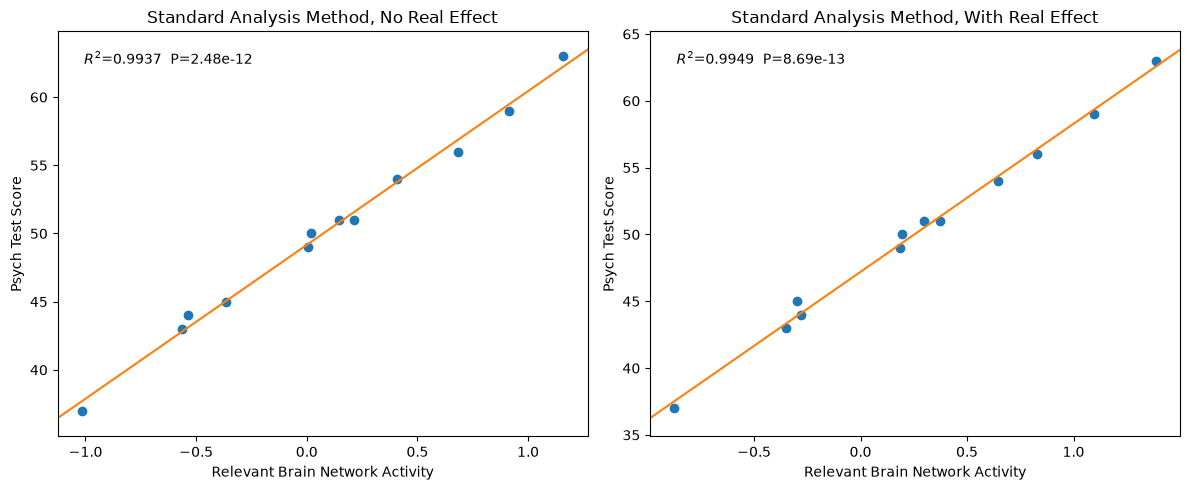

In [8]:
def annotate_corr(ax, rbna, T, title):
    ax.plot(rbna, T, "o", color="tab:blue", markerfacecolor="tab:blue")
    bestfit_line(ax, rbna, T)
    ax.set_xlabel("Relevant Brain Network Activity")
    ax.set_ylabel("Psych Test Score")
    ax.set_title(title)
    r_model, p_model = stats.pearsonr(rbna, T)
    Rsquared = r_model ** 2
    xlims, ylims = ax.get_xlim(), ax.get_ylim()
    xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
    ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
    ax.text(xpos, ypos, f"$R^2$={Rsquared:.4f}  P={p_model:.2e}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
annotate_corr(axes[0], RBNA, T, "Standard Analysis Method, No Real Effect")
annotate_corr(axes[1], RBNA_real, T, "Standard Analysis Method, With Real Effect")
plt.tight_layout()
plt.show()

## What to think about (interpreting the two plots)

Compare the two panels. In the **left** panel (no real effect) the ground truth is that
brain activity is completely unrelated to the psychology test — yet the scatter typically
shows a convincing-looking positive trend with a high $R^2$ and a small $p$ value. This is a
**false positive**. In the **right** panel (real effect) we see a similar-looking trend.

The uncomfortable observation: the false positive from the null simulation looks about as
convincing — in $R^2$, $p$ value, and scatter plot — as the true positive. On the strength of
these plots alone you generally *cannot* tell a false positive from a real effect.

*(Optional extension, per step 6 of the assignment: wrap the Question 1 simulation in a loop
that draws a fresh random null data set 1,000–10,000 times, and count what fraction of runs
produce a "significant" result, e.g. $p < 0.01$. You would find the false-positive rate is far
above the nominal 1%.)*

## Question 3 — What is wrong with this workflow?

The flaw is **circular analysis**, also called **"double dipping"** or non-independence
error. The *same* 12 subjects' data are used twice:

1. First to **select** the voxels — we keep exactly those voxels that happen to correlate
   positively with $T$ in this particular sample.
2. Then to **test** the correlation — we re-measure the correlation between $T$ and the average
   of those hand-picked voxels.

Because the selection step cherry-picks voxels whose *noise* happens to align with $T$, the
averaged network is guaranteed to correlate with $T$ in the same sample even when no true
relationship exists. The final correlation test is therefore not valid: its null distribution
is not the standard one, so the reported $p$ value is meaningless.

**A better (independent) workflow** — split the data so that selection and testing use
different observations. For example:

- **Cross-validation / data splitting:** select the "modulated" voxels using one subset of
  subjects (or scan runs), then compute RBNA and test its correlation with $T$ on a *held-out*
  subset that played no part in selection.
- **A fully independent localizer:** define the voxel set from separate data (e.g. an
  independent task-localizer scan), then apply it to the experimental data.

Applied to the null data (Question 1) this independent approach brings the false-positive rate
back down to the nominal level (~1% at $p<0.01$), so spurious correlations largely disappear.
Applied to the real-effect data (Question 2) it still detects the genuine effect — with lower
power than the (invalid) circular method, but with a trustworthy $p$ value.


---

# SOLUTION: Leave-one-out cross-validation 
Break the circularity by using different sets of subjects to select the voxels and test the correlation.

With only 12 subjects, **leave-one-out cross-validation (LOO-CV)** is a natural choice:

* **Fold $i$** (for $i = 1 \ldots N_\text{subj}$):
  1. Use the $N_\text{subj} - 1$ *training* subjects to select voxels
     (same criteria as before: $r > 0.1$, $p < 0.05$).
  2. Compute the RBNA for the *held-out* subject $i$ by averaging the
     activity in those training-derived voxels.

After all folds, the held-out RBNA values are assembled into a vector of length
$N_\text{subj}$ and correlated with $T$.  Because no subject's data influenced both the
voxel-selection step and its own RBNA value, this correlation is statistically valid.

The helper below implements the loop; it returns `RBNA_cv` (one entry per subject) and
the number of voxels selected in each fold (useful for diagnostics).

In [9]:
def loo_cv_rbna(DA, T):
    """Leave-one-out cross-validated RBNA.

    For each held-out subject i, voxels are selected on the other N-1 subjects
    using the same criteria as the standard analysis (r > 0.1, p < 0.05),
    then RBNA is computed for subject i on those held-out voxels.

    Returns
    -------
    RBNA_cv : ndarray, shape (Nsubj,)
        Cross-validated RBNA; NaN where no voxels were selected in that fold.
    n_vox : list of int
        Number of voxels selected in each fold (diagnostic).
    """
    Nsubj = DA.shape[0]
    RBNA_cv = np.full(Nsubj, np.nan)
    n_vox = []

    for i in range(Nsubj):
        train_idx = np.delete(np.arange(Nsubj), i)
        r_tr, p_tr = corr_columns(DA[train_idx], T[train_idx])
        mod_vox = np.where((r_tr > 0.1) & (p_tr < 0.05))[0]
        n_vox.append(mod_vox.size)
        if mod_vox.size > 0:
            RBNA_cv[i] = DA[i, mod_vox].mean()

    return RBNA_cv, n_vox

In [10]:
# Apply LOO-CV to both datasets
RBNA_cv_null, nvox_null = loo_cv_rbna(DA, T)
RBNA_cv_real, nvox_real = loo_cv_rbna(DA_real, T)

print("Null data (no real effect):")
print(f"  Avg voxels selected per fold : {np.mean(nvox_null):.1f}  "
      f"(range {min(nvox_null)}–{max(nvox_null)})")
print(f"  Folds with ≥1 voxel selected : {np.sum(np.array(nvox_null) > 0)}/{Nsubj}")

print("\nReal-effect data:")
print(f"  Avg voxels selected per fold : {np.mean(nvox_real):.1f}  "
      f"(range {min(nvox_real)}–{max(nvox_real)})")
print(f"  Folds with ≥1 voxel selected : {np.sum(np.array(nvox_real) > 0)}/{Nsubj}")

Null data (no real effect):
  Avg voxels selected per fold : 113.7  (range 104–132)
  Folds with ≥1 voxel selected : 12/12

Real-effect data:
  Avg voxels selected per fold : 149.6  (range 123–160)
  Folds with ≥1 voxel selected : 12/12


### Comparison plots: circular analysis vs. LOO-CV

Four panels show the scatter of RBNA vs. test score $T$ for all four combinations.
In the LOO-CV plots only subjects whose fold produced at least one selected voxel are shown
(all subjects in practice with `Nvox = 5000`).

**Expected outcome:** the null-data CV panel should show a weak, non-significant
correlation ($p \gg 0.05$) while the real-effect CV panel should still show a positive
trend, though with a less extreme $R^2$ than the (invalid) circular version.

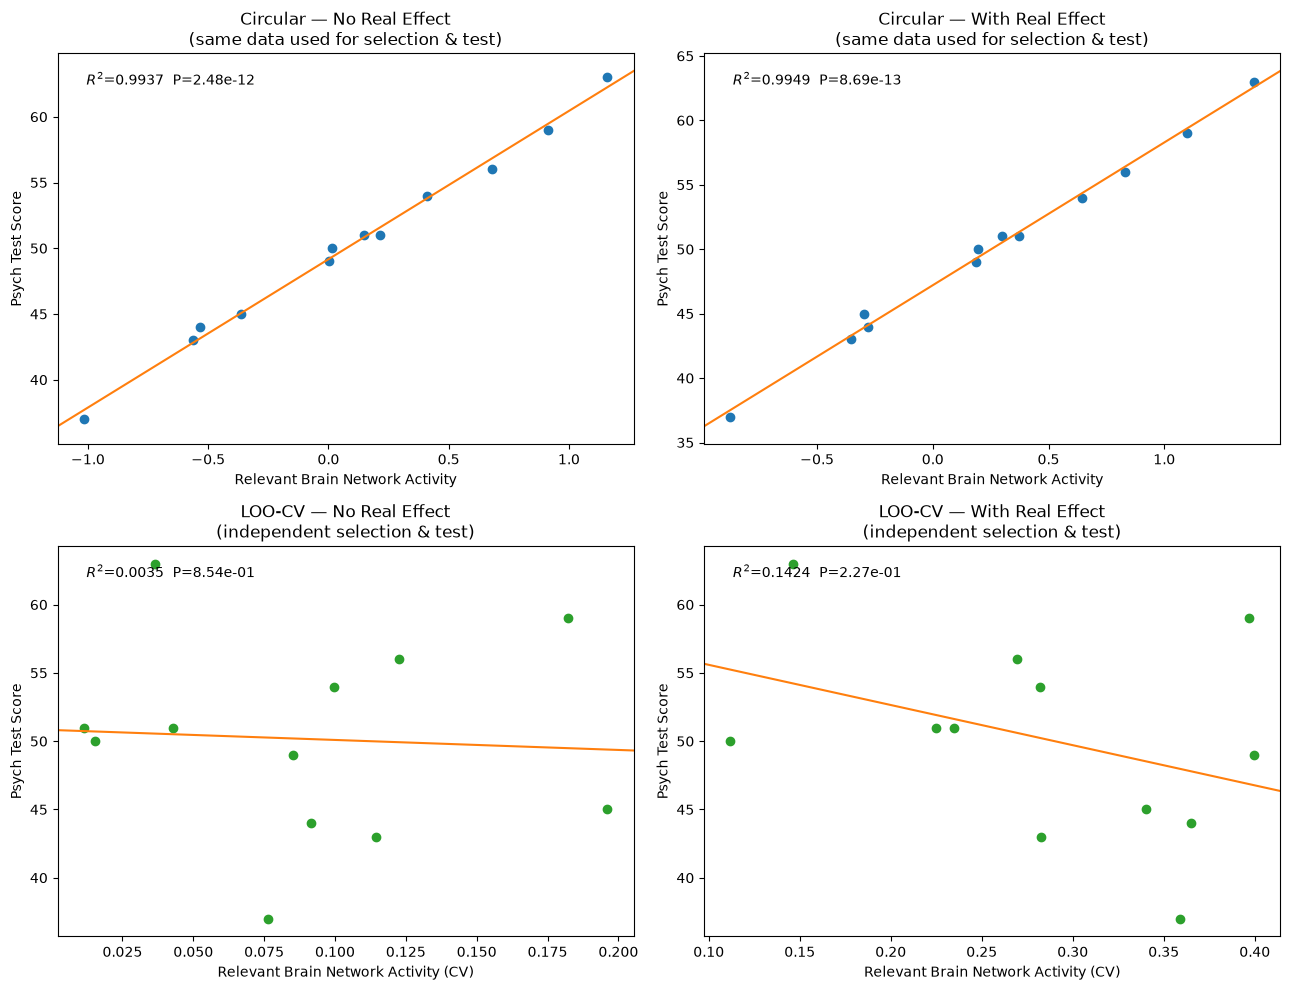

In [11]:
def annotate_corr_cv(ax, rbna, T, title):
    """Like annotate_corr but handles NaN entries from LOO-CV."""
    mask = ~np.isnan(rbna)
    rbna_valid, T_valid = rbna[mask], T[mask]
    ax.plot(rbna_valid, T_valid, "o", color="tab:green", markerfacecolor="tab:green")
    bestfit_line(ax, rbna_valid, T_valid)
    ax.set_xlabel("Relevant Brain Network Activity (CV)")
    ax.set_ylabel("Psych Test Score")
    ax.set_title(title)
    if T_valid.size >= 3:
        r_cv, p_cv = stats.pearsonr(rbna_valid, T_valid)
        Rsq = r_cv ** 2
        xlims, ylims = ax.get_xlim(), ax.get_ylim()
        xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
        ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
        ax.text(xpos, ypos, f"$R^2$={Rsq:.4f}  P={p_cv:.2e}")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 1 — circular (standard) analysis
annotate_corr(axes[0, 0], RBNA, T,
              "Circular — No Real Effect\n(same data used for selection & test)")
annotate_corr(axes[0, 1], RBNA_real, T,
              "Circular — With Real Effect\n(same data used for selection & test)")

# Row 2 — LOO-CV (independent) analysis
annotate_corr_cv(axes[1, 0], RBNA_cv_null, T,
                 "LOO-CV — No Real Effect\n(independent selection & test)")
annotate_corr_cv(axes[1, 1], RBNA_cv_real, T,
                 "LOO-CV — With Real Effect\n(independent selection & test)")

plt.tight_layout()
plt.show()

### Rejecting the true positive?
This method prevents us from detecting the false positive in the no real effect dataset, but we also don't see a true positive result in the dataset with a real effect. What if we try increasing the strength of the real effect? 

In [12]:
# simulate a stronger effect, k = 0.5
k_strong = 0.5  # modest correlation between task-related signal and trait
Tscaled_strong = (k_strong * sA / np.std(T, ddof=1)) * (T - np.mean(T)) + mA

DA_real_strong = np.empty((Nsubj, Nvox))
for i in range(Nsubj):
    DA_real_strong[i, TaskDependentVoxels] = (
        sA * rng.standard_normal(Naffected) + Tscaled_strong[i]
    )
DA_real_strong[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))

r2, p2 = corr_columns(DA_real_strong, T)
ModulatedVoxels_real_strong = np.where((r2 > 0.1) & (p2 < 0.05))[0]
RBNA_real_strong = DA_real_strong[:, ModulatedVoxels_real_strong].mean(axis=1)
print(f"Number of 'relevant' voxels selected: {ModulatedVoxels_real_strong.size}")

Number of 'relevant' voxels selected: 276


In [13]:
RBNA_cv_real_strong, nvox_real_strong = loo_cv_rbna(DA_real_strong, T)

print("\nWeak real-effect data:")
print(f"  Avg voxels selected per fold : {np.mean(nvox_real):.1f}  "
      f"(range {min(nvox_real)}–{max(nvox_real)})")
print(f"  Folds with ≥1 voxel selected : {np.sum(np.array(nvox_real) > 0)}/{Nsubj}")

print("\nStrong real-effect data:")
print(f"  Avg voxels selected per fold : {np.mean(nvox_real_strong):.1f}  "
      f"(range {min(nvox_real_strong)}–{max(nvox_real_strong)})")
print(f"  Folds with ≥1 voxel selected : {np.sum(np.array(nvox_real_strong) > 0)}/{Nsubj}")


Weak real-effect data:
  Avg voxels selected per fold : 149.6  (range 123–160)
  Folds with ≥1 voxel selected : 12/12

Strong real-effect data:
  Avg voxels selected per fold : 260.1  (range 222–277)
  Folds with ≥1 voxel selected : 12/12


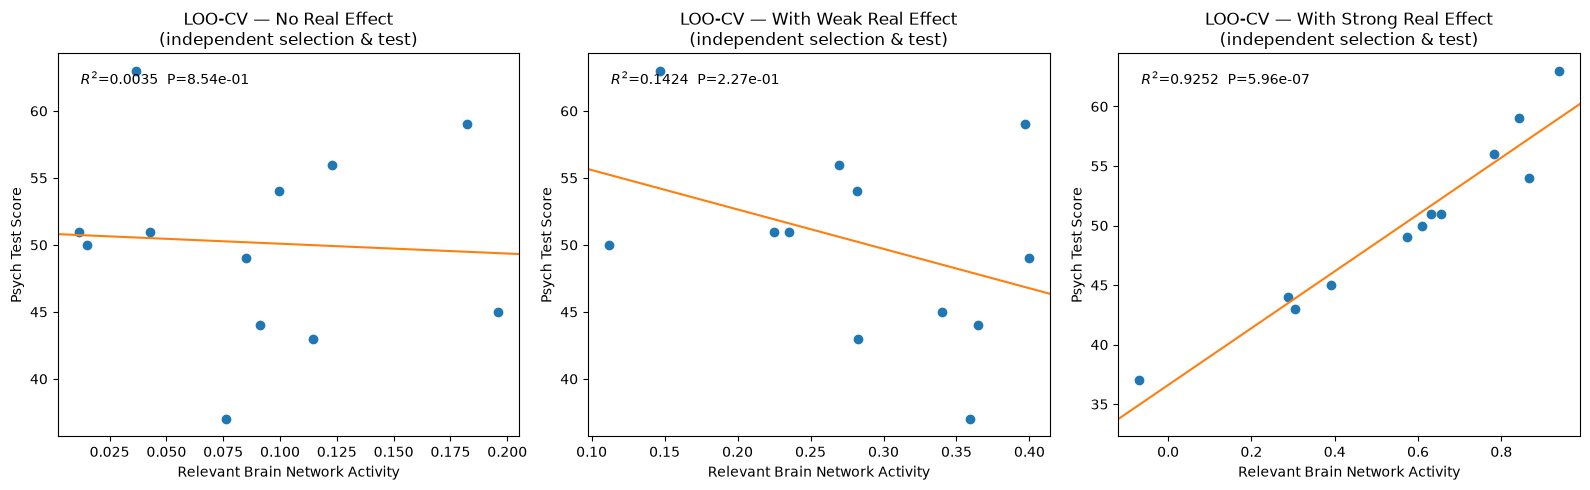

In [14]:
# plot the results for LOO-CV - no effect, weak effect, strong effect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


annotate_corr(axes[0], RBNA_cv_null, T,
             "LOO-CV — No Real Effect\n(independent selection & test)")


annotate_corr(axes[1], RBNA_cv_real, T,
              "LOO-CV — With Weak Real Effect\n(independent selection & test)")

annotate_corr(axes[2], RBNA_cv_real_strong, T,
              "LOO-CV — With Strong Real Effect\n(independent selection & test)")

plt.tight_layout()
plt.show()

---

## Alternative: Independent Voxel Selection by Task Effect

The LOO-CV approach fixes double-dipping but pays a power cost: each fold's voxels are
selected on only $N-1$ subjects, and with $N=12$ and a weak effect ($k=0.2$) that is not
enough to reliably detect the true correlation.

A more powerful valid approach is to **change the voxel-selection criterion** so that it
is independent of $T$ by construction.  Instead of selecting voxels that correlate with
the psychology score, we select voxels that are **activated by the task** — i.e., those
whose mean differential activity across subjects is significantly greater than zero.

Concretely, for each voxel we run a one-sample $t$-test (across subjects) against zero
and keep voxels with $p < 0.05$ (one-tailed, testing mean $> 0$).  Because this criterion
does not involve $T$ at all, there is no circularity: the full $N=12$ subjects can be
used for both selection and the subsequent correlation test.


In [17]:
def task_based_rbna(DA):
    """Select voxels by task activation (one-sample t-test, mean > 0, p < 0.05).

    The criterion involves only the task effect, never T, so no cross-validation
    is needed — all subjects can be used for both selection and correlation.

    Returns
    -------
    RBNA_task : ndarray, shape (Nsubj,)
    n_selected : int
    """
    n = DA.shape[0]
    vox_means = DA.mean(axis=0)
    vox_se = DA.std(axis=0, ddof=1) / np.sqrt(n)
    with np.errstate(divide="ignore", invalid="ignore"):
        t_vals = vox_means / vox_se
    p_vals = stats.t.sf(t_vals, df=n - 1)   # one-tailed: mean > 0
    selected = np.where(p_vals < 0.05)[0]
    RBNA_task = DA[:, selected].mean(axis=1) if selected.size > 0 else np.full(n, np.nan)
    return RBNA_task, selected.size


RBNA_task_null, n_task_null = task_based_rbna(DA)
RBNA_task_real, n_task_real = task_based_rbna(DA_real)
RBNA_task_real_strong, n_task_real_strong = task_based_rbna(DA_real_strong)

print(f"Null data  — voxels selected by task effect: {n_task_null}")
print(f"Real data (weak effect)  — voxels selected by task effect: {n_task_real}")
print(f"Real data (strong effect)  — voxels selected by task effect: {n_task_real_strong}")

Null data  — voxels selected by task effect: 661
Real data (weak effect)  — voxels selected by task effect: 706
Real data (strong effect)  — voxels selected by task effect: 686


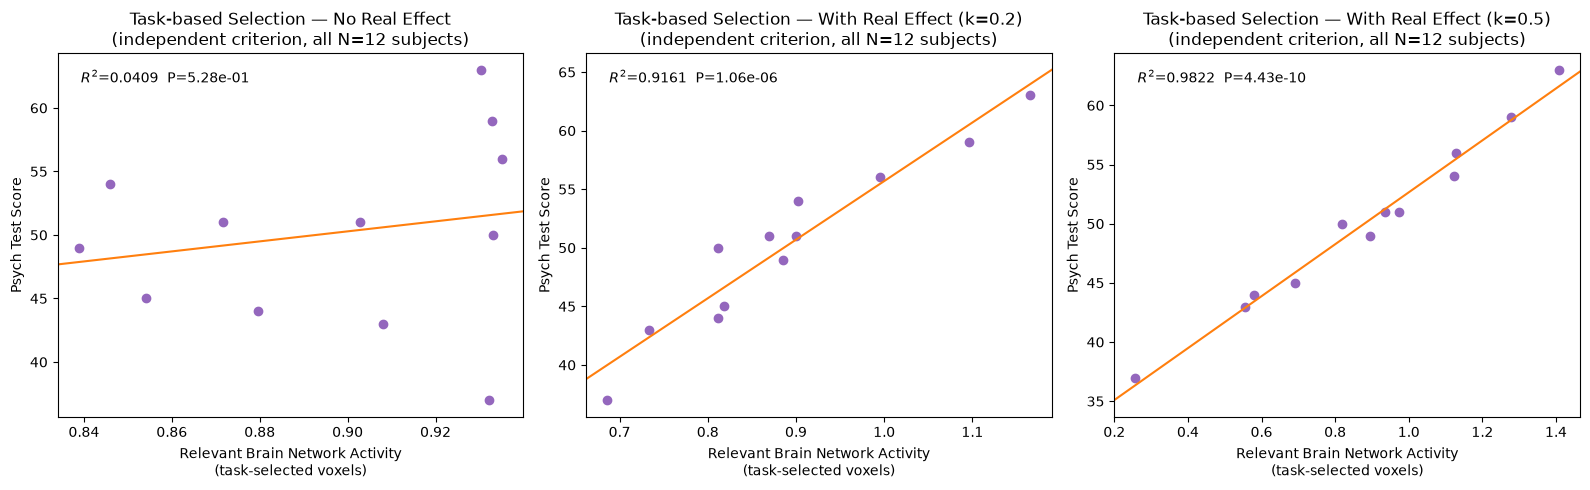

In [18]:
def annotate_corr_task(ax, rbna, T, title, color="tab:purple"):
    """Scatter + best-fit line for task-based RBNA (handles NaN)."""
    mask = ~np.isnan(rbna)
    rbna_v, T_v = rbna[mask], T[mask]
    ax.plot(rbna_v, T_v, "o", color=color, markerfacecolor=color)
    bestfit_line(ax, rbna_v, T_v)
    ax.set_xlabel("Relevant Brain Network Activity\n(task-selected voxels)")
    ax.set_ylabel("Psych Test Score")
    ax.set_title(title)
    if T_v.size >= 3:
        r_t, p_t = stats.pearsonr(rbna_v, T_v)
        Rsq = r_t ** 2
        xlims, ylims = ax.get_xlim(), ax.get_ylim()
        xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
        ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
        ax.text(xpos, ypos, f"$R^2$={Rsq:.4f}  P={p_t:.2e}")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
annotate_corr_task(axes[0], RBNA_task_null, T,
                   "Task-based Selection — No Real Effect\n(independent criterion, all N=12 subjects)")
annotate_corr_task(axes[1], RBNA_task_real, T,
                   f"Task-based Selection — With Real Effect (k={k})\n(independent criterion, all N=12 subjects)")
annotate_corr_task(axes[2], RBNA_task_real_strong, T,
                   f"Task-based Selection — With Real Effect (k={k_strong})\n(independent criterion, all N=12 subjects)")
plt.tight_layout()
plt.show()

This method successfully returned no effect in the no effect dataset, but was able to detect a true positive in both the weak and strong effect datasets. 

### False-positive rate — all three methods



A single simulation run is not enough to measure the false-positive rate — one run
either passes or fails the significance threshold by chance.  To estimate the actual
false-positive rate we repeat the **null simulation** (no real effect) many times and
count how often each method incorrectly declares a significant result.

The loop below runs `N_iter = 1000` fresh null datasets.  For each:

1. Draw new `DA` (only `T` stays fixed — the design is fixed, the brain data are resampled).
2. Run the **circular** analysis and record whether the final $p < \alpha$.
3. Run the **LOO-CV** analysis and record whether the final $p < \alpha$.
4. Run the **Task-based** analysis and record whether the final $p < \alpha$.

At $\alpha = 0.01$ the nominal false-positive rate is 1%.  We expect the circular
method to be *far* above that, and the LOO-CV and task-based methods to be close to it.


| Method | Selection criterion | Subjects used for selection | Subjects used for final test |
|---|---|---|---|
| Circular | Correlation with $T$ | All 12 | Same 12 |
| LOO-CV | Correlation with $T$ | 11 (held one out) | All 12 (assembled) |
| Task-based | Task effect (mean $> 0$) | All 12 | All 12 |

**Expected outcome:** circular far above nominal, LOO-CV and task-based both near nominal (∼1%), with task-based having somewhat better power to detect the real effect.

In [19]:
N_iter2 = 1000
alpha2 = 0.01

counts = {"circular": 0, "loo_cv": 0, "task": 0}

for _ in range(N_iter2):
    DA_mc = np.empty((Nsubj, Nvox))
    DA_mc[:, TaskDependentVoxels] = sA * rng.standard_normal((Nsubj, Naffected)) + mA
    DA_mc[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))

    # Circular
    r_mc, p_mc = corr_columns(DA_mc, T)
    mod_mc = np.where((r_mc > 0.1) & (p_mc < 0.05))[0]
    if mod_mc.size > 0:
        _, p_circ = stats.pearsonr(DA_mc[:, mod_mc].mean(axis=1), T)
        if p_circ < alpha2:
            counts["circular"] += 1

    # LOO-CV
    RBNA_cv_mc, _ = loo_cv_rbna(DA_mc, T)
    mask = ~np.isnan(RBNA_cv_mc)
    if mask.sum() >= 3:
        _, p_cv = stats.pearsonr(RBNA_cv_mc[mask], T[mask])
        if p_cv < alpha2:
            counts["loo_cv"] += 1

    # Task-based
    RBNA_task_mc, n_sel = task_based_rbna(DA_mc)
    if n_sel > 0:
        _, p_task = stats.pearsonr(RBNA_task_mc, T)
        if p_task < alpha2:
            counts["task"] += 1

for name, cnt in counts.items():
    print(f"  {name:10s}  FP rate = {cnt/N_iter2:.1%}  ({cnt}/{N_iter2})")
print(f"  nominal α  = {alpha2:.1%}")

  circular    FP rate = 100.0%  (1000/1000)
  loo_cv      FP rate = 8.1%  (81/1000)
  task        FP rate = 0.4%  (4/1000)
  nominal α  = 1.0%


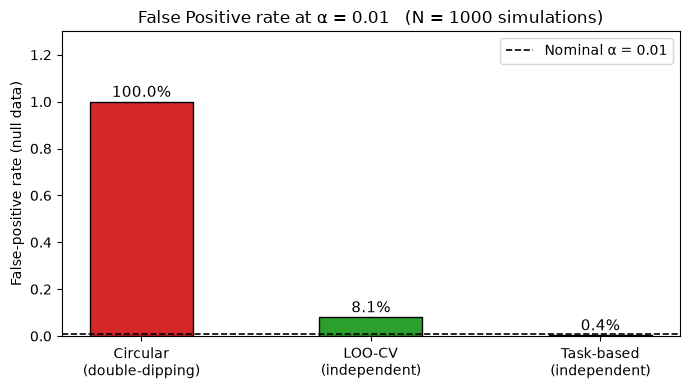

In [20]:
labels = ["Circular\n(double-dipping)", "LOO-CV\n(independent)", "Task-based\n(independent)"]
rates2 = [counts[k] / N_iter2 for k in ("circular", "loo_cv", "task")]
colors2 = ["tab:red", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, rates2, color=colors2, width=0.45, edgecolor="k")
ax.axhline(alpha2, color="k", linestyle="--", linewidth=1.2, label=f"Nominal α = {alpha2}")
ax.set_ylabel("False-positive rate (null data)")
ax.set_title(f"False Positive rate at α = {alpha2}   (N = {N_iter2} simulations)")
ax.set_ylim(0, max(rates2) * 1.3)
for bar, rate in zip(bars, rates2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

---

## Power Curves: Effect Size and Sample Size Sweeps

Here we measure **power** — the true-positive rate on real-effect data — across two parameter sweeps:

1. **Effect-size sweep** — $k$ from 0.1 to 1.0 in steps of 0.1, with $N = 12$ fixed.
   Shows the minimum effect size each method can reliably detect.

2. **Sample-size sweep** — $N$ from 5 to 25 in steps of 1, with $k = 0.2$ fixed.
   Shows how many subjects each method needs to reach adequate power.

For each combination, `N_iter_power` real-effect datasets are simulated and the
fraction of runs that produce $p < \alpha$ is recorded.  $T$ and the voxel layout are
resampled fresh each run so the estimate reflects genuine variability.

> **Note on the circular method:** its "power" includes spurious detections arising
> from the circular selection bias — the high curve is not evidence of a trustworthy
> method, but of an inflated false-positive rate carrying over into real-effect data.

In [21]:
def power_sweep(param_values, param_name, N_iter, alpha, k_fixed=0.2, N_fixed=12):
    """Estimate detection power for each value of k (effect size) or N (sample size).

    Simulates real-effect data for each parameter value and returns the fraction
    of runs where each method correctly reaches p < alpha.

    Parameters
    ----------
    param_values : array-like
    param_name   : 'k' or 'N'
    N_iter       : simulations per parameter value
    alpha        : significance threshold
    k_fixed      : effect size used when sweeping N
    N_fixed      : sample size used when sweeping k
    """
    power = {m: [] for m in ("circular", "loo_cv", "task")}

    for val in param_values:
        k_val = float(val) if param_name == "k" else k_fixed
        N_val = int(val)   if param_name == "N" else N_fixed
        counts = {"circular": 0, "loo_cv": 0, "task": 0}

        for _ in range(N_iter):
            # Fresh T for this run
            T_sim = np.round(sT * rng.standard_normal(N_val) + mT)
            std_T = np.std(T_sim, ddof=1)
            if std_T < 1e-10:
                continue

            # Real-effect brain data: task-dependent voxels modulated by T
            Tscaled_sim = (k_val * sA / std_T) * (T_sim - np.mean(T_sim)) + mA
            DA_sim = sA * rng.standard_normal((N_val, Nvox))
            DA_sim[:, TaskDependentVoxels] += Tscaled_sim[:, np.newaxis]

            # Circular
            r_s, p_s = corr_columns(DA_sim, T_sim)
            mod_s = np.where((r_s > 0.1) & (p_s < 0.05))[0]
            if mod_s.size > 0:
                _, p_circ = stats.pearsonr(DA_sim[:, mod_s].mean(axis=1), T_sim)
                if p_circ < alpha:
                    counts["circular"] += 1

            # LOO-CV
            RBNA_cv_s, _ = loo_cv_rbna(DA_sim, T_sim)
            cv_mask = ~np.isnan(RBNA_cv_s)
            if cv_mask.sum() >= 3:
                _, p_cv = stats.pearsonr(RBNA_cv_s[cv_mask], T_sim[cv_mask])
                if p_cv < alpha:
                    counts["loo_cv"] += 1

            # Task-based
            RBNA_task_s, n_sel = task_based_rbna(DA_sim)
            if n_sel > 0:
                _, p_task = stats.pearsonr(RBNA_task_s, T_sim)
                if p_task < alpha:
                    counts["task"] += 1

        for m in power:
            power[m].append(counts[m] / N_iter)

    return power

In [22]:
N_iter_power = 200   # increase to 500–1000 for smoother curves (takes longer)
alpha_power  = 0.05  # standard threshold for power analysis

k_values = np.round(np.arange(0.1, 1.01, 0.1), 2)   # [0.1, 0.2, ..., 1.0]
N_values = np.arange(5, 26, 1)                        # [5, 6, ..., 25]

print(f"Running effect-size sweep ({len(k_values)} k values × {N_iter_power} iterations) …")
power_k = power_sweep(k_values, "k", N_iter_power, alpha_power, N_fixed=12)
print("  done.")

print(f"Running sample-size sweep ({len(N_values)} N values × {N_iter_power} iterations) …")
power_N = power_sweep(N_values, "N", N_iter_power, alpha_power, k_fixed=0.2)
print("  done.")

Running effect-size sweep (10 k values × 200 iterations) …
  done.
Running sample-size sweep (21 N values × 200 iterations) …
  done.


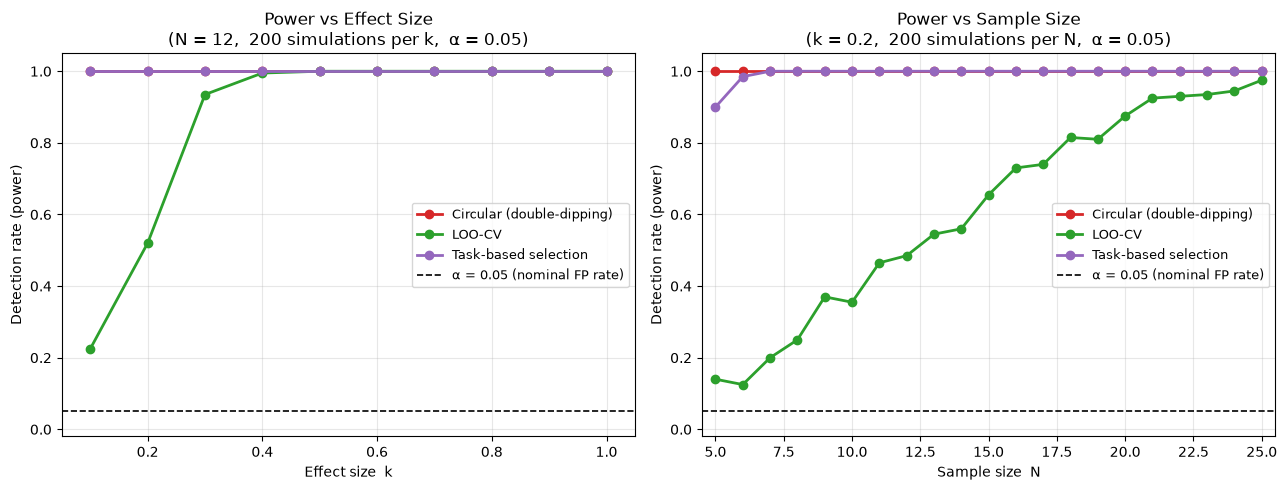

In [23]:
method_styles = {
    "circular": ("tab:red",    "Circular (double-dipping)"),
    "loo_cv":   ("tab:green",  "LOO-CV"),
    "task":     ("tab:purple", "Task-based selection"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: power vs effect size k (N=12 fixed)
ax = axes[0]
for m, (color, label) in method_styles.items():
    ax.plot(k_values, power_k[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Effect size  k")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Effect Size\n(N = 12,  {N_iter_power} simulations per k,  α = {alpha_power})")
ax.set_xlim(k_values[0] - 0.05, k_values[-1] + 0.05)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: power vs sample size N (k=0.2 fixed)
ax = axes[1]
for m, (color, label) in method_styles.items():
    ax.plot(N_values, power_N[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Sample size  N")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Sample Size\n(k = 0.2,  {N_iter_power} simulations per N,  α = {alpha_power})")
ax.set_xlim(N_values[0] - 0.5, N_values[-1] + 0.5)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()